# ============================================================
# PROBLEM STATEMENT
# ============================================================

# The main aim of this project is to segment customers
# based on their Annual Income and Spending Score
# using the K-Means clustering algorithm.

# Different customers have different purchasing behaviors.
# This project helps identify similar customer groups
# such as premium customers, budget customers,
# and average customers.

# Customer segmentation helps businesses improve:
# • Marketing strategies
# • Customer targeting
# • Business decisions
# • Customer satisfaction

# The Elbow Method is used to find the optimal
# number of clusters, and graphs are used to
# visualize customer groups clearly.
# ============================================================

In [3]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
# STEP 2: LOAD DATASET

data = pd.read_csv("Mall_Customers.csv")

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
# STEP 3: CHECK DATASET INFORMATION

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [6]:
# STEP 4: CHECK MISSING VALUES

print(data.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
# STEP 5: CHECK DUPLICATE VALUES

print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


In [8]:
# STEP 6: DISPLAY DATASET COLUMNS

print(data.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [9]:
# STEP 7: SELECT IMPORTANT FEATURES

X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


C:\Users\SATHWIKA\AppData\Local\Temp\ipykernel_12588\3460231564.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


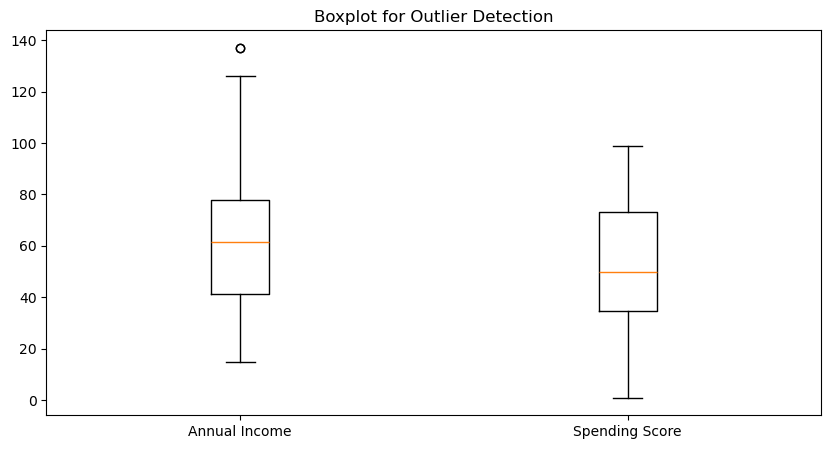

In [10]:
# STEP 8: CHECK OUTLIERS USING BOXPLOT

plt.figure(figsize=(10, 5))

plt.boxplot(
    [
        data["Annual Income (k$)"],
        data["Spending Score (1-100)"]
    ],
    labels=[
        "Annual Income",
        "Spending Score"
    ]
)

plt.title("Boxplot for Outlier Detection")

plt.show()

In [ ]:
# STEP 9: REMOVE OUTLIERS USING IQR METHOD

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
X_no_outliers = X[
    ~(
        (X < lower_limit) |
        (X > upper_limit)
    ).any(axis=1)
]

print("Original Shape:", X.shape)
print("After Removing Outliers:", X_no_outliers.shape)

Original Shape: (200, 2)
After Removing Outliers: (198, 2)


In [ ]:
# STEP 10: APPLY FEATURE SCALING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_outliers)
print(X_scaled[:5])

[[-1.77917141 -0.43598941]
 [-1.77917141  1.19941337]
 [-1.73944701 -1.72094874]
 [-1.73944701  1.04366072]
 [-1.69972262 -0.39705125]]


In [ ]:


import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

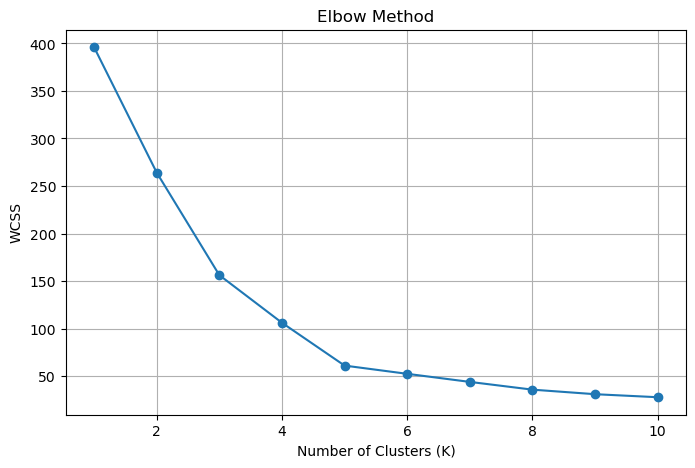

In [17]:
# STEP 10: USE ELBOW METHOD TO FIND BEST K VALUE
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [18]:
# STEP 11: TRAIN K-MEANS MODEL
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)

In [19]:
# STEP 12: ADD CLUSTER COLUMN

X_no_outliers["Cluster"] = clusters
print(X_no_outliers.head())

   Annual Income (k$)  Spending Score (1-100)  Cluster
0                  15                      39        4
1                  15                      81        0
2                  16                       6        4
3                  16                      77        0
4                  17                      40        4


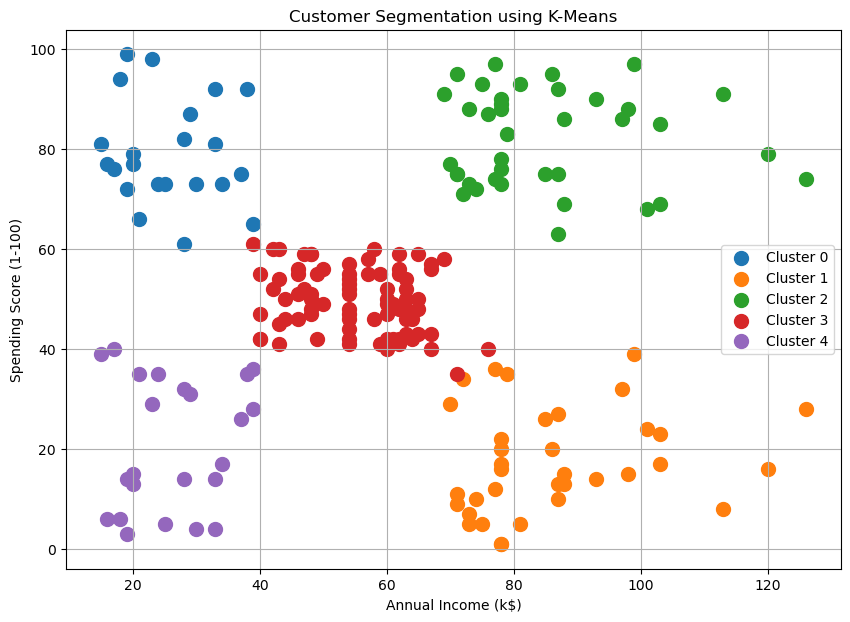

In [20]:
# STEP 13: VISUALIZE CUSTOMER CLUSTERS

plt.figure(figsize=(10, 7))
for cluster in range(5):
    plt.scatter(
        X_no_outliers[
            X_no_outliers["Cluster"] == cluster
        ]["Annual Income (k$)"],
        X_no_outliers[
            X_no_outliers["Cluster"] == cluster
        ]["Spending Score (1-100)"],
        s=100,
        label=f"Cluster {cluster}"
    )
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()

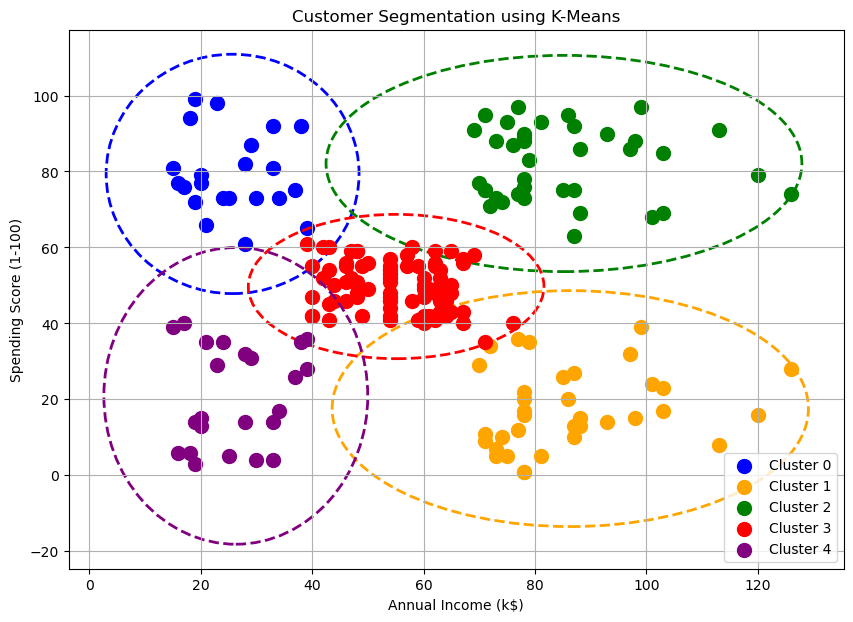

In [ ]:
# STEP 13: VISUALIZE CUSTOMER CLUSTERS WITH CIRCLES

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
plt.figure(figsize=(10,7))
colors = ['blue', 'orange', 'green', 'red', 'purple']
# Plot clusters
for cluster in range(5):
    cluster_data = X_no_outliers[
        X_no_outliers["Cluster"] == cluster
    ]
    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        s=100,
        color=colors[cluster],
        label=f"Cluster {cluster}"
    )
    # Calculate center
    center_x = cluster_data["Annual Income (k$)"].mean()
    center_y = cluster_data["Spending Score (1-100)"].mean()
    # Calculate spread
    width = cluster_data["Annual Income (k$)"].std() * 6
    height = cluster_data["Spending Score (1-100)"].std() * 6
    # Draw circle/ellipse
    ellipse = Ellipse(
        (center_x, center_y),
        width=width,
        height=height,
        edgecolor=colors[cluster],
        facecolor='none',
        linestyle='--',
        linewidth=2
    )
    plt.gca().add_patch(ellipse)

# Graph Title
plt.title("Customer Segmentation using K-Means")
# X Label
plt.xlabel("Annual Income (k$)")
# Y Label
plt.ylabel("Spending Score (1-100)")
# Show Legend
plt.legend()
# Grid
plt.grid(True)
# Show Graph
plt.show()

# ============================================================
# EXPLANATION OF CLUSTERS
# ============================================================

# Cluster 0:
# Low Income - High Spending Customers
# These customers spend more even with lower income.

# Cluster 1:
# High Income - Low Spending Customers
# These customers earn more but spend less.

# Cluster 2:
# High Income - High Spending Customers
# These are premium and most valuable customers.

# Cluster 3:
# Medium Income - Medium Spending Customers
# These are regular and balanced customers.

# Cluster 4:
# Low Income - Low Spending Customers
# These customers spend less and prefer budget products.

# ============================================================

In [21]:
# STEP 14: DISPLAY CLUSTER SUMMARY
print(
    X_no_outliers.groupby("Cluster").mean()
)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 25.727273               79.363636
1                 86.342857               17.571429
2                 85.210526               82.105263
3                 55.087500               49.712500
4                 26.304348               20.913043
